# Imports and Settings

In [2]:
import pickle
import warnings
from typing import List, Optional, Tuple

import numpy as np
import optuna
import pandas as pd
from catboost import CatBoostClassifier, Pool
from optuna.integration import CatBoostPruningCallback
from optuna.samplers import TPESampler
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

In [3]:
"""
Отключаем вывод предупреждений, связанных с экспериментальным статусом 
CatBoostPruningCallback  в библиотеке Optuna
"""
warnings.filterwarnings(
    "ignore", message="CatBoostPruningCallback is experimental", category=Warning
)

# Functions

In [9]:
def catboost_optuna_aggressive(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    seed: int = 0,
    iterations: int = 3000,
    n_trials: int = 100,
    n_startup_trials: int = 10,
    n_warmup_steps: int = 50,
    cat_features: Optional[List[str]] = None,
    study_name: str = "study_fold",
) -> Tuple[CatBoostClassifier, float]:
    """
    Выполняет автоматизированный подбор гиперпараметров для CatBoostClassifier
    с помощью библиотеки Optuna.
    Для тренировочных данных подбираются оптимальные гиперпараметры,
    обучается модель на всех данных и оценивается AUC на валидационной выборке.
    AUC на тестовой выборке выводится в консоль.

    Args:
    X_train: матрица признаков обучающей выборки.
    y_train: целевая переменная обучающей выборки.
    X_val: матрица признаков валидационной выборки.
    y_val: целевая переменная валидационной выборки.
    X_test: матрица признаков тестовой выборки.
    y_test: целевая переменная тестовой выборки.
    seed: зерно рандома для воспроизводимости (по умолчанию 0).
    iterations: максимальное число деревьев для каждой модели CatBoost (по умолчанию 3000).
    n_trials: количество испытаний Optuna для подбора гиперпараметров на каждом фолде (по умолчанию 100).
    n_startup_trials : количество первых trials, к которым не применяется pruning (по умолчанию 10)
    n_warmup_steps : количество первых итераций модели, к которым не применяется pruning (по умолчанию 10).
    cat_features : Список имён категориальных признаков (по умолчанию None).
    study_name : Имя study для записи в базу данных результатов выполненных trials.

    Returns:
    Tuple: кортеж из обученной модели и её AUC на валидационной выборке.
    """

    def plot_optimization_history(study):
        """
        Функция визуализации прогресса оптимизации ГП.
        """
        fig = optuna.visualization.plot_optimization_history(study)
        fig.show()

    def trial_callback(study, trial):
        """
        Функция подсчета выполненных и обрезанных trials.
        """
        nonlocal completed_trials, pruned_trials
        if trial.state == optuna.trial.TrialState.COMPLETE:
            completed_trials += 1
        elif trial.state == optuna.trial.TrialState.PRUNED:
            pruned_trials += 1

    """
    Создадим переменные для отслеживания количества итераций 
    для финальной модели. 
    """
    best_auc = 0
    best_iteration = 0

    def objective(trial):
        """
        Целевая функция для оптимизации гиперпараметров с помощью Optuna.
        Принимает объект trial и возвращает метрику качества (AUC)
        для текущего набора параметров.
        """
        nonlocal best_iteration, best_auc

        # Определяем пространство поисков ГП
        boosting_type = trial.suggest_categorical("boosting_type", ["Plain", "Ordered"])
        if boosting_type == "Ordered":
            grow_policy = "SymmetricTree"
        else:
            grow_policy = trial.suggest_categorical(
                "grow_policy", ["Depthwise", "Lossguide", "SymmetricTree"]
            )
        params = {
            "boosting_type": boosting_type,
            "grow_policy": grow_policy,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "depth": trial.suggest_int("depth", 3, 12),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 20),
            "random_strength": trial.suggest_float("random_strength", 1e-9, 10.0),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
            "border_count": trial.suggest_int("border_count", 32, 128),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "rsm": trial.suggest_float("rsm", 0.5, 1.0),
        }
        # Инициализируем модель trial
        model = CatBoostClassifier(
            **params,
            iterations=iterations,
            early_stopping_rounds=100,
            eval_metric="AUC",
            random_seed=seed,
            verbose=False,
            auto_class_weights="Balanced",
        )
        """
        Инициализируем pruning_callback для досрочного завершения
        неэффективных trials.
        """
        pruning_callback = CatBoostPruningCallback(trial, "AUC")

        # Обучаем  модель trial
        model.fit(
            train_pool,
            eval_set=val_pool,
            callbacks=[pruning_callback],
            use_best_model=True,
        )
        # Выбрасывает исключение TrialPruned для прерывания trial
        pruning_callback.check_pruned()

        # Получаем AUC на валидации
        proba = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, proba)

        if auc > best_auc:
            best_auc = auc
            print("new best_auc", best_auc)

            best_iteration = model.get_best_iteration()
            print("new best_iteration", best_iteration)

        return auc

    if cat_features is None:
        cat_features = []
    # Создаём объекты Pool для обучения и валидации
    train_pool = Pool(data=X_train, label=y_train, cat_features=cat_features)
    val_pool = Pool(data=X_val, label=y_val, cat_features=cat_features)

    # Счётчики выполненных и обрезанных trials
    completed_trials = 0
    pruned_trials = 0

    """
    Создаём сэмплер TPE (Tree-structured Parzen Estimator) — алгоритм оптимизации 
    гиперпараметров, использующий вероятностные модели для выбора лучших вариантов
    """
    sampler = TPESampler(seed=seed)
    """
    Инициализируем MedianPruner — прунинг на основе медианного значения,
    который пропускает первые n_warmup_steps trials без прерывания
    """
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=n_startup_trials, n_warmup_steps=n_warmup_steps
    )
    """
    Механизм сохранения статистики выполненных trials на случай прерывания.
    При повторном запуске функции выполняется ровно столько новых trials,
    сколько указано в параметре n_trials, счёт пойдёт со следующего trials после 
    failed trial(после прерывания) или N+1 при n_trials = N. 
    Ускорение работы алгоритма достигается благодаря тому, 
    что Optuna сохраняет данные о завершённых trials и может сразу после возобновления 
    прерывать неперспективные trials с помощью pruning.
    """

    # Optuna использует SQLite для хранения результатов study между запусками.
    storage = "sqlite:///../models/optuna_catboost.db"
    # Пробуем загрузить study из БД
    try:
        study = optuna.load_study(study_name=study_name, storage=storage)
        print(f"{study_name} loaded from storage")
    # Либо cоздаём новый study
    except KeyError:
        study = optuna.create_study(
            study_name=study_name,
            direction="maximize",
            sampler=sampler,
            pruner=pruner,
            storage=storage,
        )
        print(f"Created {study_name}", flush=True)

    # Запускаем study
    study.optimize(objective, n_trials=n_trials, callbacks=[trial_callback])
    # Визуализируем оптимизацию ГП
    plot_optimization_history(study)

    print("Optuna study best value:", study.best_value)
    print("Completed trials:", completed_trials)
    print("Pruned trials:", pruned_trials)

    # Посмотрим на выбранный набор ГП
    print("The best hyperparameters of the study:", study.best_params)

    best_params = study.best_params.copy()
    if best_iteration != 0:
        best_params["iterations"] = best_iteration
    else:
        best_params["iterations"] = 100

    print("Final model hyperparameters:", best_params)

    # Объединяем train и val по строкам
    X_train_val = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
    y_train_val = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

    # Создаём Pool из объединённых данных
    train_pool = Pool(data=X_train_val, label=y_train_val, cat_features=cat_features)

    final_model = CatBoostClassifier(
        **best_params, random_seed=seed, verbose=False, auto_class_weights="Balanced"
    )
    final_model.fit(train_pool)

    # Получаем  AUC на валидации
    proba = final_model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, proba)
    print("AUC final_model val", val_auc)

    # Выводим в консоль AUC на тесте
    proba = final_model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, proba)
    print("AUC final_model test", test_auc)

    return final_model, val_auc

In [10]:
def catboost_optuna_conservative(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    seed: int = 0,
    iterations: int = 3000,
    n_trials: int = 100,
    n_startup_trials: int = 10,
    n_warmup_steps: int = 50,
    cat_features: Optional[List[str]] = None,
    study_name: str = "study_fold",
) -> Tuple[CatBoostClassifier, float]:
    """
    Выполняет автоматизированный подбор гиперпараметров для CatBoostClassifier
    с помощью библиотеки Optuna.
    Для тренировочных данных подбираются оптимальные гиперпараметры,
    на тренировочных данных данного фолда (train-части) обучается финальная модель и
    оценивается AUC на валидационной выборке.
    AUC на тестовой выборке выводится в консоль.

    Args:
    X_train: матрица признаков обучающей выборки.
    y_train: целевая переменная обучающей выборки.
    X_val: матрица признаков валидационной выборки.
    y_val: целевая переменная валидационной выборки.
    X_test: матрица признаков тестовой выборки.
    y_test: целевая переменная тестовой выборки.
    seed: зерно рандома для воспроизводимости (по умолчанию 0).
    iterations: максимальное число деревьев для каждой модели CatBoost (по умолчанию 3000).
    n_trials: количество испытаний Optuna для подбора гиперпараметров на каждом фолде (по умолчанию 100).
    n_startup_trials : количество первых trials, к которым не применяется pruning (по умолчанию 10)
    n_warmup_steps : количество первых итераций модели, к которым не применяется pruning (по умолчанию 10).
    cat_features : Список имён категориальных признаков (по умолчанию None).
    study_name : Имя study для записи в базу данных результатов выполненных trials.

    Returns:
    Tuple: кортеж из обученной модели и её AUC на валидационной выборке.
    """

    def plot_optimization_history(study):
        """
        Функция визуализации прогресса оптимизации ГП.
        """
        fig = optuna.visualization.plot_optimization_history(study)
        fig.show()

    def trial_callback(study, trial):
        """
        Функция подсчета выполненных и обрезанных trials.
        """
        nonlocal completed_trials, pruned_trials
        if trial.state == optuna.trial.TrialState.COMPLETE:
            completed_trials += 1
        elif trial.state == optuna.trial.TrialState.PRUNED:
            pruned_trials += 1

    def objective(trial):
        """
        Целевая функция для оптимизации гиперпараметров с помощью Optuna.
        Принимает объект trial и возвращает метрику качества (AUC)
        для текущего набора параметров.
        """
        # Определяем пространство поисков ГП
        boosting_type = trial.suggest_categorical("boosting_type", ["Plain", "Ordered"])
        if boosting_type == "Ordered":
            grow_policy = "SymmetricTree"
        else:
            grow_policy = trial.suggest_categorical(
                "grow_policy", ["Depthwise", "Lossguide", "SymmetricTree"]
            )
        params = {
            "boosting_type": boosting_type,
            "grow_policy": grow_policy,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "depth": trial.suggest_int("depth", 3, 12),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 20),
            "random_strength": trial.suggest_float("random_strength", 1e-9, 10.0),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
            "border_count": trial.suggest_int("border_count", 32, 128),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "rsm": trial.suggest_float("rsm", 0.5, 1.0),
        }
        # Инициализируем модель trial
        model = CatBoostClassifier(
            **params,
            iterations=iterations,
            early_stopping_rounds=100,
            eval_metric="AUC",
            random_seed=seed,
            verbose=False,
            auto_class_weights="Balanced",
        )
        """
        Инициализируем pruning_callback для досрочного завершения
        неэффективных trials.
        """
        pruning_callback = CatBoostPruningCallback(trial, "AUC")

        # Обучаем  модель trial
        model.fit(
            train_pool,
            eval_set=val_pool,
            callbacks=[pruning_callback],
            use_best_model=True,
        )
        # Выбрасывает исключение TrialPruned для прерывания trial
        pruning_callback.check_pruned()

        # Получаем AUC на валидации
        val_proba = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, val_proba)

        return auc

    if cat_features is None:
        cat_features = []
    # Создаём объекты Pool для обучения и валидации
    train_pool = Pool(data=X_train, label=y_train, cat_features=cat_features)
    val_pool = Pool(data=X_val, label=y_val, cat_features=cat_features)

    # Счётчики выполненных и обрезанных trials
    completed_trials = 0
    pruned_trials = 0

    """
    Создаём сэмплер TPE (Tree-structured Parzen Estimator) — алгоритм оптимизации 
    гиперпараметров, использующий вероятностные модели для выбора лучших вариантов
    """
    sampler = TPESampler(seed=seed)
    """
    Инициализируем MedianPruner — прунинг на основе медианного значения,
    который пропускает первые n_warmup_steps trials без прерывания
    """
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=n_startup_trials, n_warmup_steps=n_warmup_steps
    )
    """
    Механизм сохранения статистики выполненных trials на случай прерывания.
    При повторном запуске функции выполняется ровно столько новых trials,
    сколько указано в параметре n_trials, счёт пойдёт со следующего trials после 
    failed trial(после прерывания) или N+1 при n_trials = N. 
    Ускорение работы алгоритма достигается благодаря тому, 
    что Optuna сохраняет данные о завершённых trials и может сразу после возобновления 
    прерывать неперспективные trials с помощью pruning.
    """

    # Optuna использует SQLite для хранения результатов study между запусками.
    storage = "sqlite:///../models/optuna_catboost.db"
    # Пробуем загрузить study из БД
    try:
        study = optuna.load_study(study_name=study_name, storage=storage)
        print(f"{study_name} loaded from storage")
    # Либо cоздаём новый study
    except KeyError:
        study = optuna.create_study(
            study_name=study_name,
            direction="maximize",
            sampler=sampler,
            pruner=pruner,
            storage=storage,
        )
        print(f"Created {study_name}", flush=True)

    # Запускаем study
    study.optimize(objective, n_trials=n_trials, callbacks=[trial_callback])
    # Визуализируем оптимизацию ГП
    plot_optimization_history(study)

    print("Optuna study best value:", study.best_value)
    print("Completed trials:", completed_trials)
    print("Pruned trials:", pruned_trials)

    # Посмотрим на выбранный набор ГП
    print("The best hyperparameters of the study:", study.best_params)

    # Инициализируем и обучаем финальную модель
    final_model = CatBoostClassifier(
        **study.best_params,
        iterations=iterations,
        early_stopping_rounds=100,
        eval_metric="AUC",
        random_seed=seed,
        verbose=False,
        auto_class_weights="Balanced",
    )
    final_model.fit(train_pool, eval_set=val_pool, use_best_model=True)
    # Получаем  AUC на валидации
    proba = final_model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, proba)
    print("AUC final_model val", val_auc)

    # Выводим в консоль AUC на тесте
    proba = final_model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, proba)
    print("AUC final_model test", test_auc)

    return final_model, val_auc

# Aggressive scheme (Kaggle-style)

Выполним автоматизированный подбор гиперпараметров для CatBoostClassifier с помощью библиотеки Optuna.      
Тренировочный датасет разбивается на 5 фолдов.    
Для каждого фолда подбираются оптимальные гиперпараметры и на всех тренировочных    
данных обучается финальная модель.
Оценивается её AUC на валидационной и тестовой выборках.    

Для финального предсказания на тестовой выборке      
формируется  средневзвешенное предсказание ансамбля моделей:     
предсказания всех моделей усредняются через их AUC на валидационных выборках.     

In [4]:
df_train = pd.read_csv("../data/processed/cut_corr_imp_train.csv")
df_test = pd.read_csv("../data/processed/cut_corr_imp_test.csv")
df_train.shape, df_test.shape

((2400000, 61), (600000, 61))

In [5]:
X = df_train.drop(["id", "flag"], axis=1)
y = df_train.flag
X.shape, y.shape

((2400000, 59), (2400000,))

In [6]:
X_test = df_test.drop(["id", "flag"], axis=1)
y_test = df_test.flag
X_test.shape, y_test.shape

((600000, 59), (600000,))

In [7]:
X_train_list = []
y_train_list = []
X_val_list = []
y_val_list = []


# Инициализируем сбалансированное разделение на фолды
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
# Итерируем по фолдам
for _i, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    X_train_list.append(X_train)
    y_train_list.append(y_train)
    X_val_list.append(X_val)
    y_val_list.append(y_val)

print(X_train_list[0].shape, y_train_list[0].shape)
print(X_val_list[0].shape, y_val_list[0].shape)

(1920000, 59) (1920000,)
(480000, 59) (480000,)


Функция catboost_optuna_aggressive имеет механизм сохранения результатов выполненных trials.   
При повторном запуске функции выполняется ровно столько новых trials,    
сколько указано в параметре n_trials, счёт пойдёт со следующего trials после    
failed trial(после прерывания) или N+1 при n_trials = N при удачном завершении первого запуска.       
Ускорение работы алгоритма достигается благодаря тому,       
что Optuna сохраняет данные о завершённых trials и может сразу после возобновления    
прерывать неперспективные trials с помощью pruning.   

In [ ]:
# Fold 0
model, val_auc = catboost_optuna_aggressive(
    X_train_list[0],
    y_train_list[0],
    X_val_list[0],
    y_val_list[0],
    X_test,
    y_test,
    seed=0,
    iterations=3_000,
    n_trials=100,
    n_startup_trials=10,
    n_warmup_steps=30,
    study_name="fold_0_aggressive",
)

Для ячеек поиска ГП  после их выполнения удалены выводы для снижения размера ноутбука и обеспечения   
возможности его просмотра в GitHub без использования дополнительных средств.   
Для наглядности представлены скриншоты частей вывода ячейки нулевого фолда.    
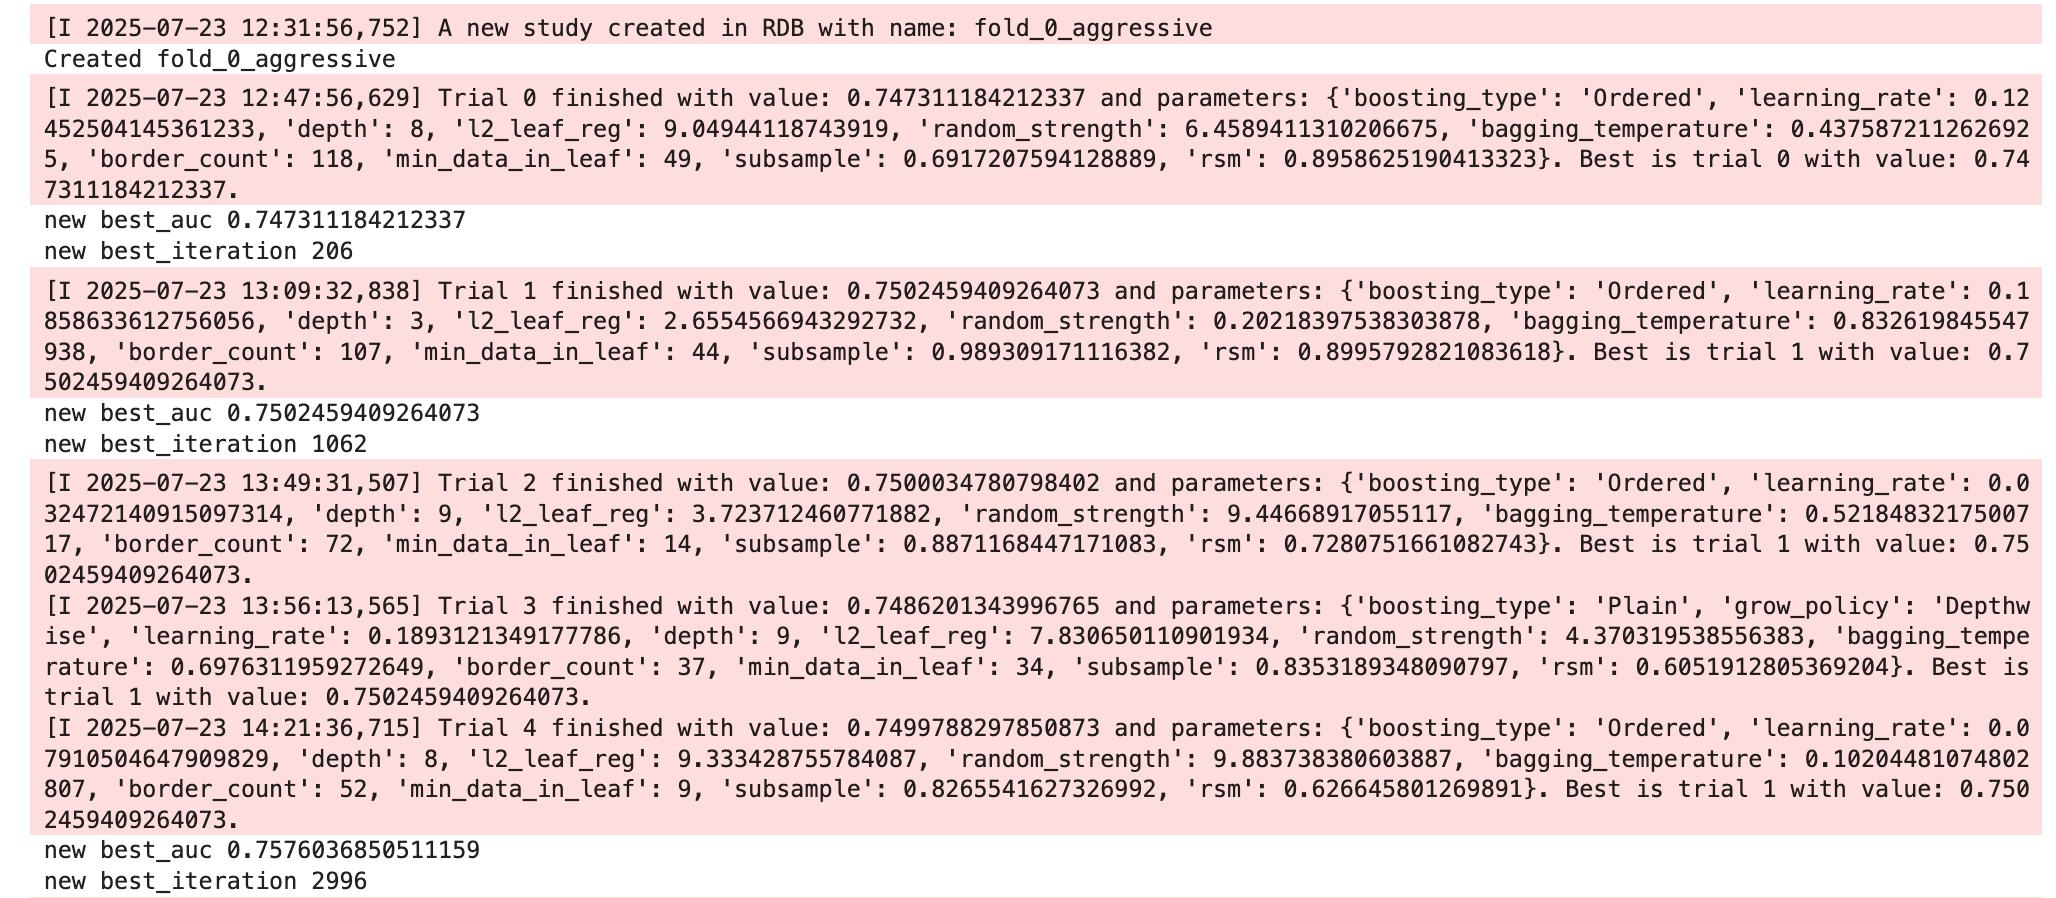
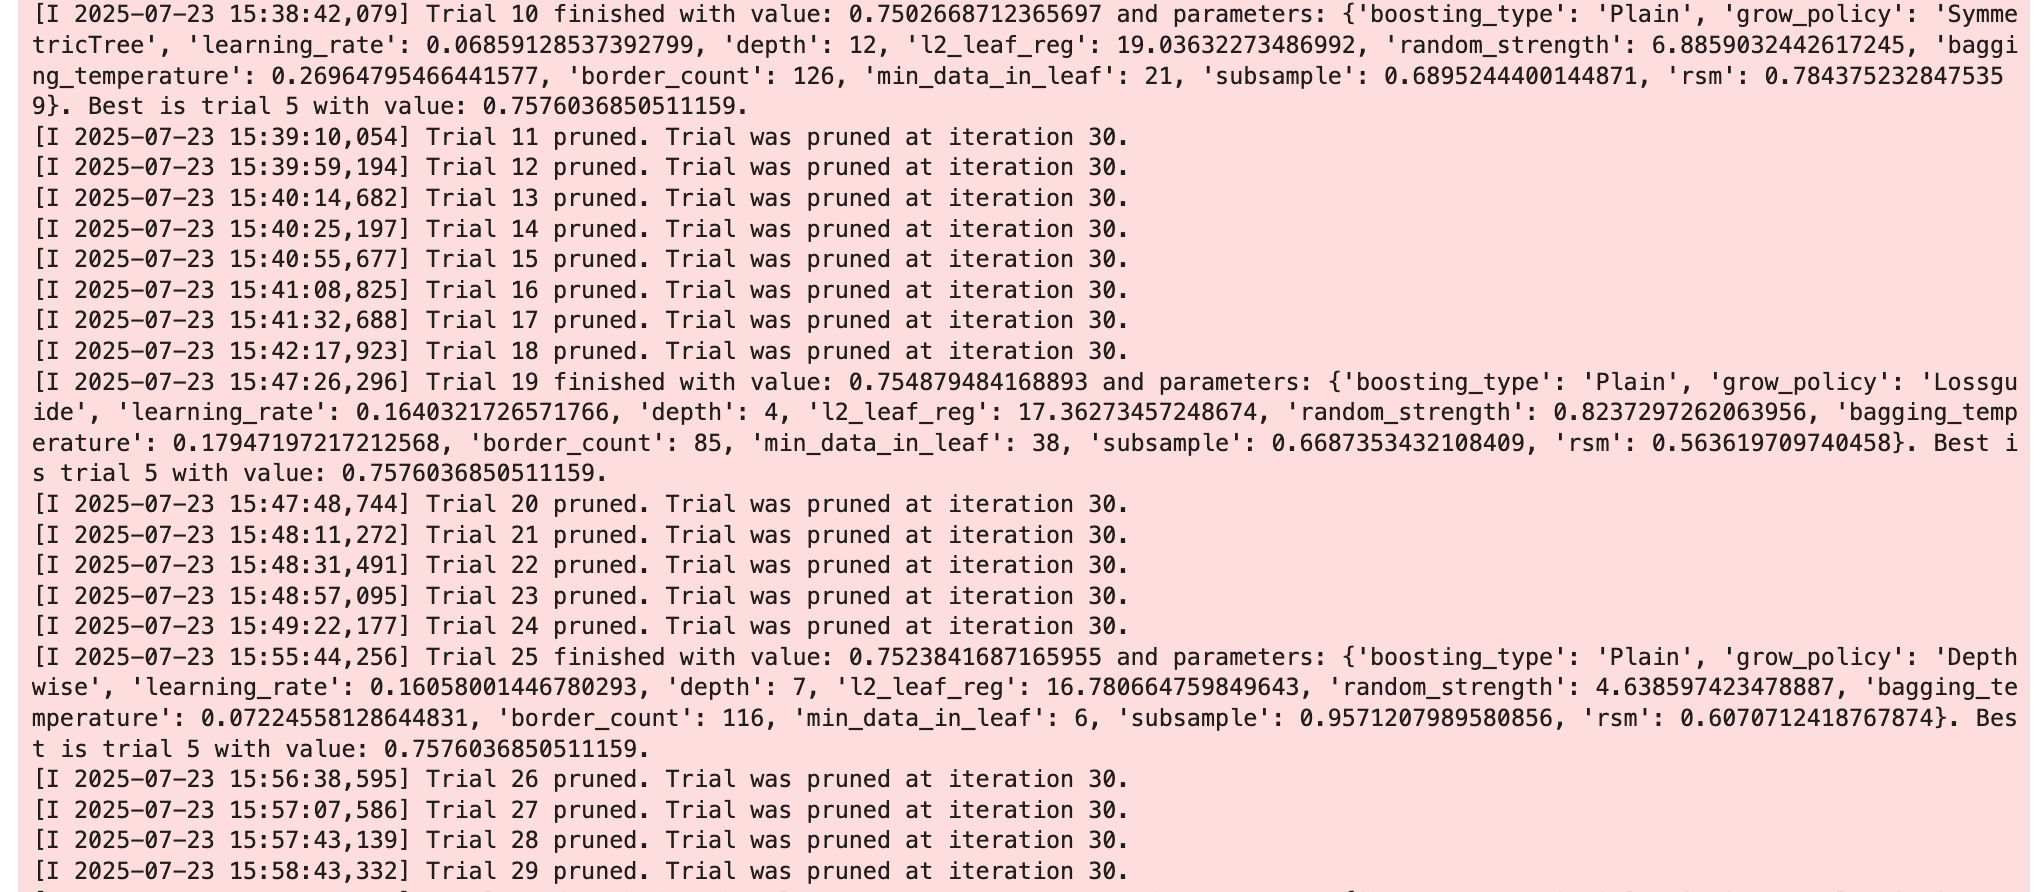
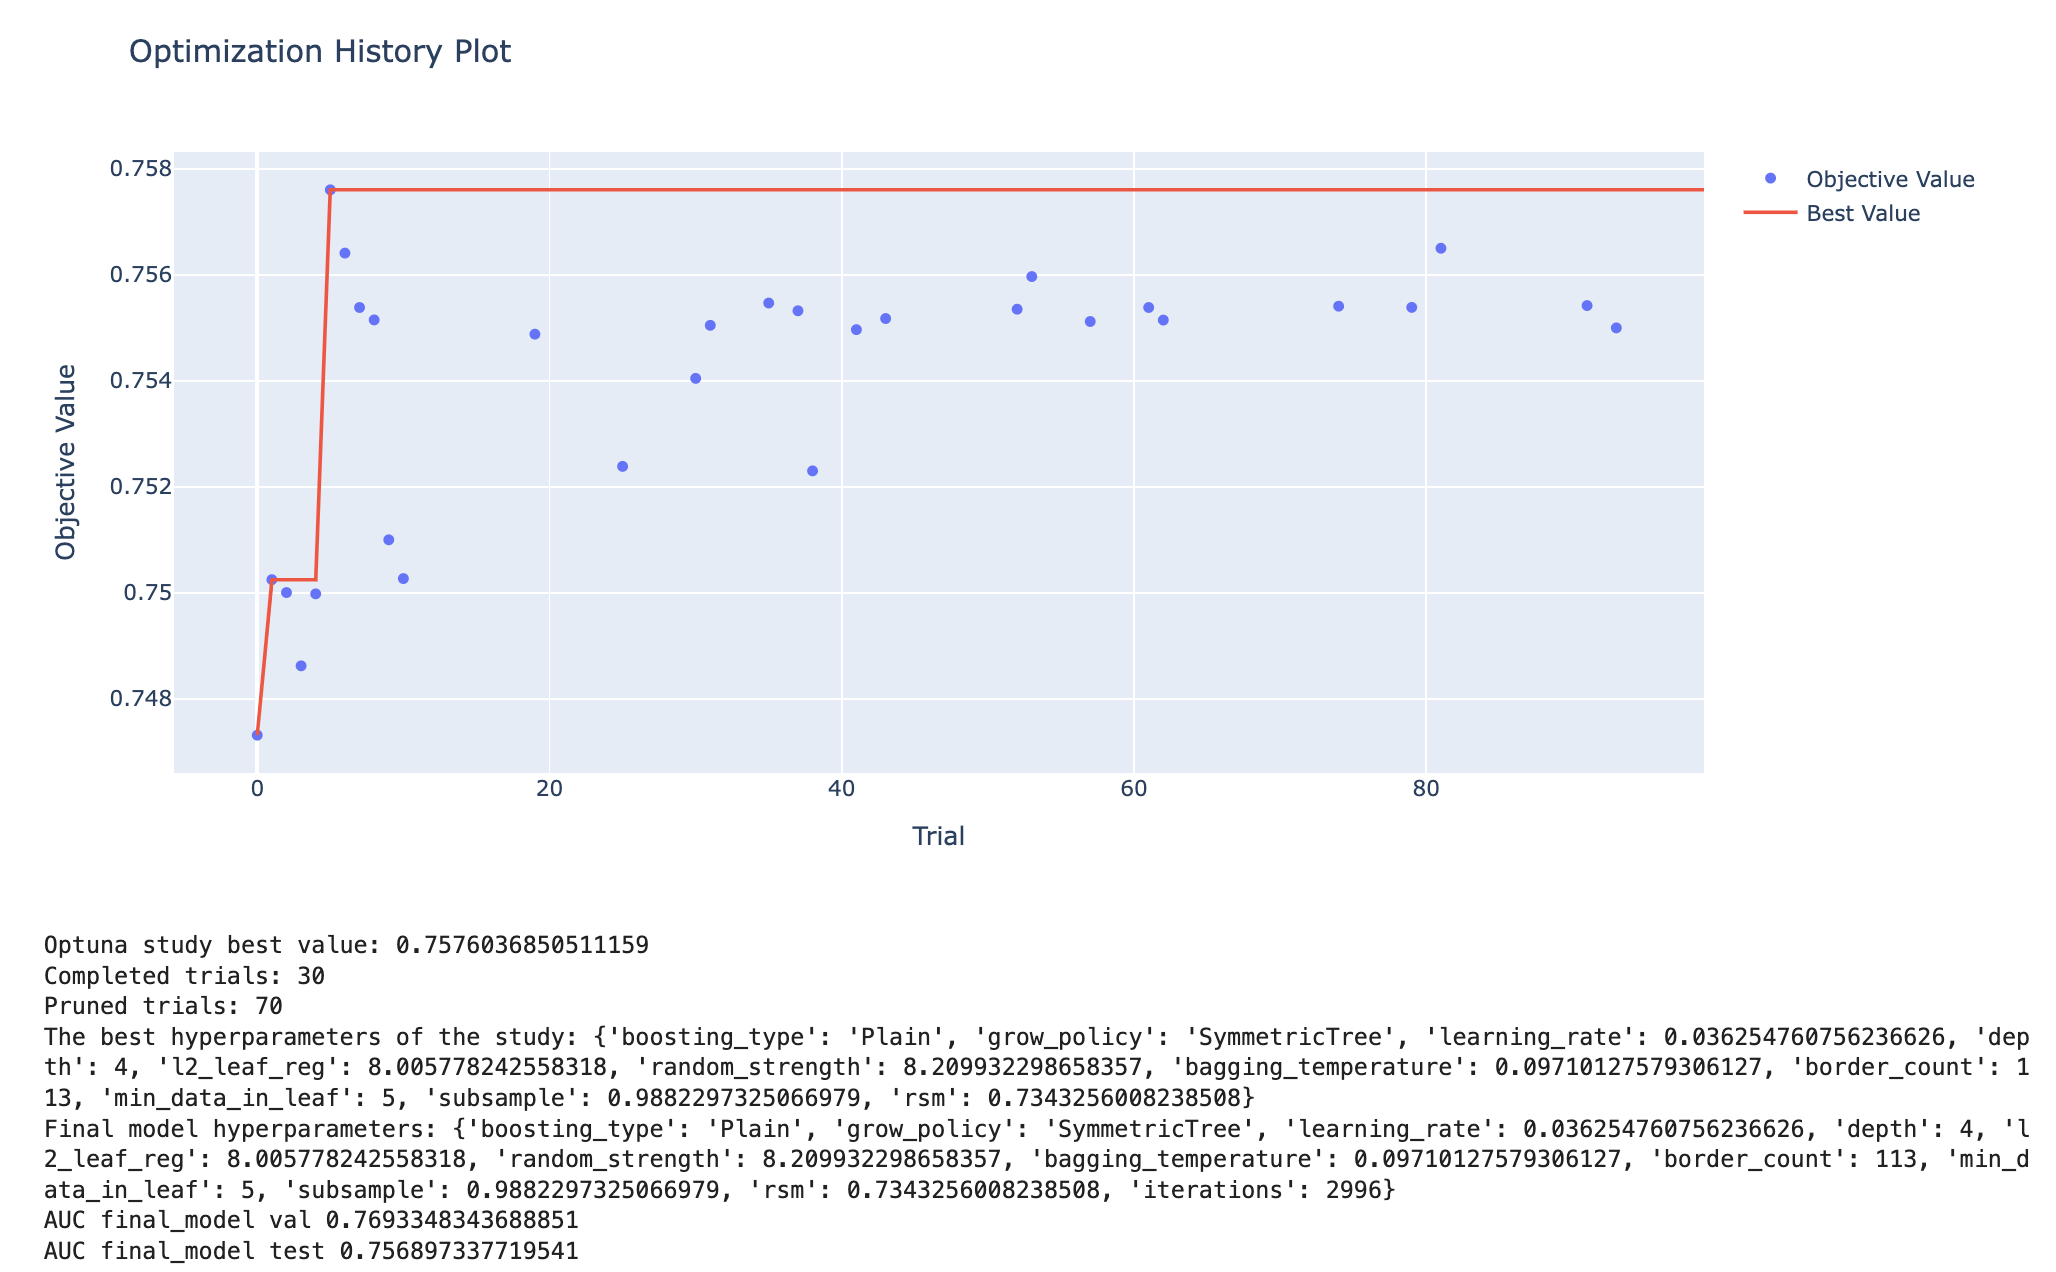


In [10]:
# Сохраненяем модель в файл
model.save_model("../models/fold_0_aggressive_model.bin")

In [ ]:
# Fold 1
model, val_auc = catboost_optuna_aggressive(
    X_train_list[1],
    y_train_list[1],
    X_val_list[1],
    y_val_list[1],
    X_test,
    y_test,
    seed=0,
    iterations=3_000,
    n_trials=100,
    n_startup_trials=10,
    n_warmup_steps=30,
    study_name="fold_1_aggressive",
)

In [12]:
# Сохраненяем модель в файл
model.save_model("../models/fold_1_aggressive_model.bin")

In [ ]:
# Fold 2
model, val_auc = catboost_optuna_aggressive(
    X_train_list[2],
    y_train_list[2],
    X_val_list[2],
    y_val_list[2],
    X_test,
    y_test,
    seed=0,
    iterations=3_000,
    n_trials=100,
    n_startup_trials=10,
    n_warmup_steps=30,
    study_name="fold_2_aggressive",
)

In [14]:
# Сохраненяем модель в файл
model.save_model("../models/fold_2_aggressive_model.bin")

In [ ]:
# Fold 3
model, val_auc = catboost_optuna_aggressive(
    X_train_list[3],
    y_train_list[3],
    X_val_list[3],
    y_val_list[3],
    X_test,
    y_test,
    seed=0,
    iterations=3_000,
    n_trials=100,
    n_startup_trials=10,
    n_warmup_steps=30,
    study_name="fold_3_aggressive",
)

In [16]:
# Сохраненяем модель в файл
model.save_model("../models/fold_3_aggressive_model.bin")

In [ ]:
# Fold 4
model, val_auc = catboost_optuna_aggressive(
    X_train_list[4],
    y_train_list[4],
    X_val_list[4],
    y_val_list[4],
    X_test,
    y_test,
    seed=0,
    iterations=3_000,
    n_trials=100,
    n_startup_trials=10,
    n_warmup_steps=30,
    study_name="fold_4_aggressive",
)

In [18]:
# Сохраненяем модель в файл
model.save_model("../models/fold_4_aggressive_model.bin")

In [19]:
# Собираем словарь с моделями
models_dict = {}
for i in range(5):
    model = CatBoostClassifier()
    model.load_model(f"../models/fold_{i}_aggressive_model.bin")
    models_dict[f"fold_{i}_aggressive_model"] = model

models_dict

{'fold_0_aggressive_model': <catboost.core.CatBoostClassifier at 0x14d3aacc0>,
 'fold_1_aggressive_model': <catboost.core.CatBoostClassifier at 0x14d3a92b0>,
 'fold_2_aggressive_model': <catboost.core.CatBoostClassifier at 0x14d3aba40>,
 'fold_3_aggressive_model': <catboost.core.CatBoostClassifier at 0x14d3a8500>,
 'fold_4_aggressive_model': <catboost.core.CatBoostClassifier at 0x14d3a8860>}

In [20]:
# Собираем список весов моделей - это их AUC на валидации
val_auc_list = []

for (_model_name, value), X_val, y_val in zip(
    models_dict.items(), X_val_list, y_val_list, strict=True
):
    pred = value.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, pred)
    val_auc_list.append(auc)

val_auc_list

[0.7693348343688851,
 0.7394622932228643,
 0.7651370914585489,
 0.7661752867843185,
 0.7647998719911736]

In [21]:
"""
На тестовых данных обираем средневзвешенный по AUC предикт
на всех моделях фолдов и финальной моделе.
"""
df_pred = pd.DataFrame()

for (model_name, value), weight in zip(models_dict.items(), val_auc_list, strict=True):
    # Получаем вероятности положительного класса
    pred = value.predict_proba(X_test)[:, 1]
    # Умножаем предсказания на вес модели
    df_pred[model_name] = pred * weight

# Суммируем веса всех моделей
weights_sum = sum(val_auc_list)
# Формируем итоговое взвешенное среднее
df_pred["ensemble_weighted_pred"] = df_pred.sum(axis=1) / weights_sum
# Получаем AUC ансамбля
auc = roc_auc_score(y_test, df_pred["ensemble_weighted_pred"])
print("AUC ensemble weighted test", auc)

AUC ensemble weighted test 0.7560340983429678


# Сonservative scheme

Выполним автоматизированный подбор гиперпараметров для CatBoostClassifier с помощью библиотеки Optuna.  
Финальная модель обучается только на тренировочных данных данного фолда (train-части).    
Тренировочный датасет разбивается на заданное количество фолдов.    
Для каждого фолда подбираются оптимальные гиперпараметры,    
обучается отдельная модель, и оценивается AUC на валидационной и тестовой выборках.    
После определяется лучший набор гиперпараметров по максимальному AUC на фолдах,    
и на всех обучающих данных обучается финальная модель с этими параметрами.    
Для финального предсказания на тестовой выборке      
формируется взвешенное среднее предсказание ансамбля моделей фолдов и     
модели обученной на всех данных:     
предсказания всех моделей усредняются весами это их AUC на валидационных выборках,    
а для модели обученной на всех данных вес модели это среднее AUC моделей фолдов.     

In [22]:
df_train = pd.read_csv("../data/processed/cut_corr_imp_train.csv")
df_test = pd.read_csv("../data/processed/cut_corr_imp_test.csv")
df_train.shape, df_test.shape

((2400000, 61), (600000, 61))

In [23]:
X = df_train.drop(["id", "flag"], axis=1)
y = df_train.flag
X.shape, y.shape

((2400000, 59), (2400000,))

In [24]:
X_test = df_test.drop(["id", "flag"], axis=1)
y_test = df_test.flag
X_test.shape, y_test.shape

((600000, 59), (600000,))

In [25]:
X_train_list = []
y_train_list = []
X_val_list = []
y_val_list = []


# Инициализируем сбалансированное разделение на фолды
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
# Итерируем по фолдам
for _i, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    X_train_list.append(X_train)
    y_train_list.append(y_train)
    X_val_list.append(X_val)
    y_val_list.append(y_val)

X_train_list[0].shape, y_train_list[0].shape

((1920000, 59), (1920000,))

In [26]:
# Словарь гиперпараметров лучшего фолда
best_all_folds_params = {}

# Список метрик фолдов на валидации
val_auc_list = []

Функция catboost_optuna_hyperparameter_search имеет механизм сохранения результатов выполненных trials.   
При повторном запуске функции выполняется ровно столько новых trials,    
сколько указано в параметре n_trials, счёт пойдёт со следующего trials после    
failed trial(после прерывания) или N+1 при n_trials = N при удачном завершении первого запуска.       
Ускорение работы алгоритма достигается благодаря тому,       
что Optuna сохраняет данные о завершённых trials и может сразу после возобновления    
прерывать неперспективные trials с помощью pruning.   

In [ ]:
# Fold 0
model, val_auc = catboost_optuna_conservative(
    X_train_list[0],
    y_train_list[0],
    X_val_list[0],
    y_val_list[0],
    X_test,
    y_test,
    seed=0,
    iterations=3_000,
    n_trials=100,
    n_startup_trials=10,
    n_warmup_steps=30,
    study_name="fold_0_conservative",
)

Для ячеек поиска ГП  после их выполнения удалены выводы для снижения размера ноутбука и обеспечения   
возможности его просмотра в GitHub без использования дополнительных средств.   
Для наглядности представлены скриншоты частей вывода ячейки нулевого фолда.    
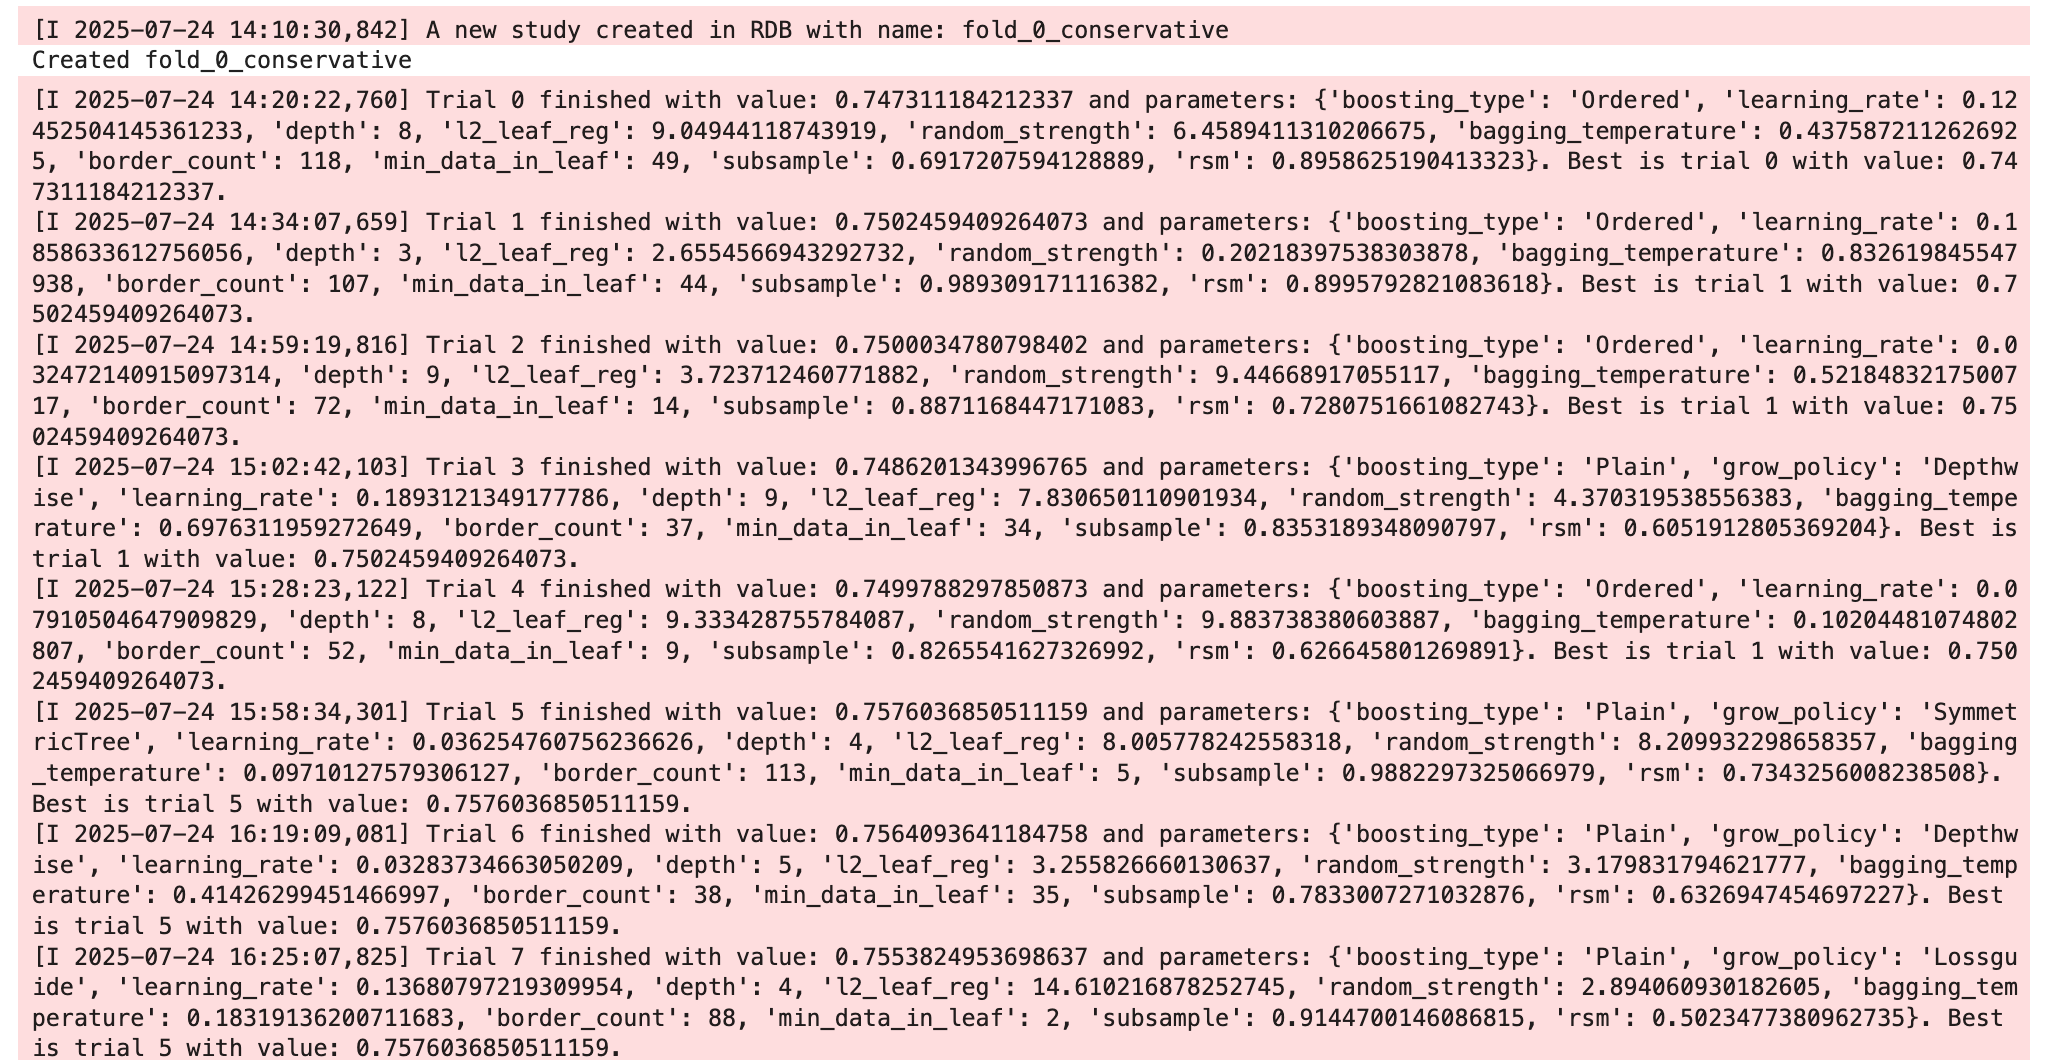
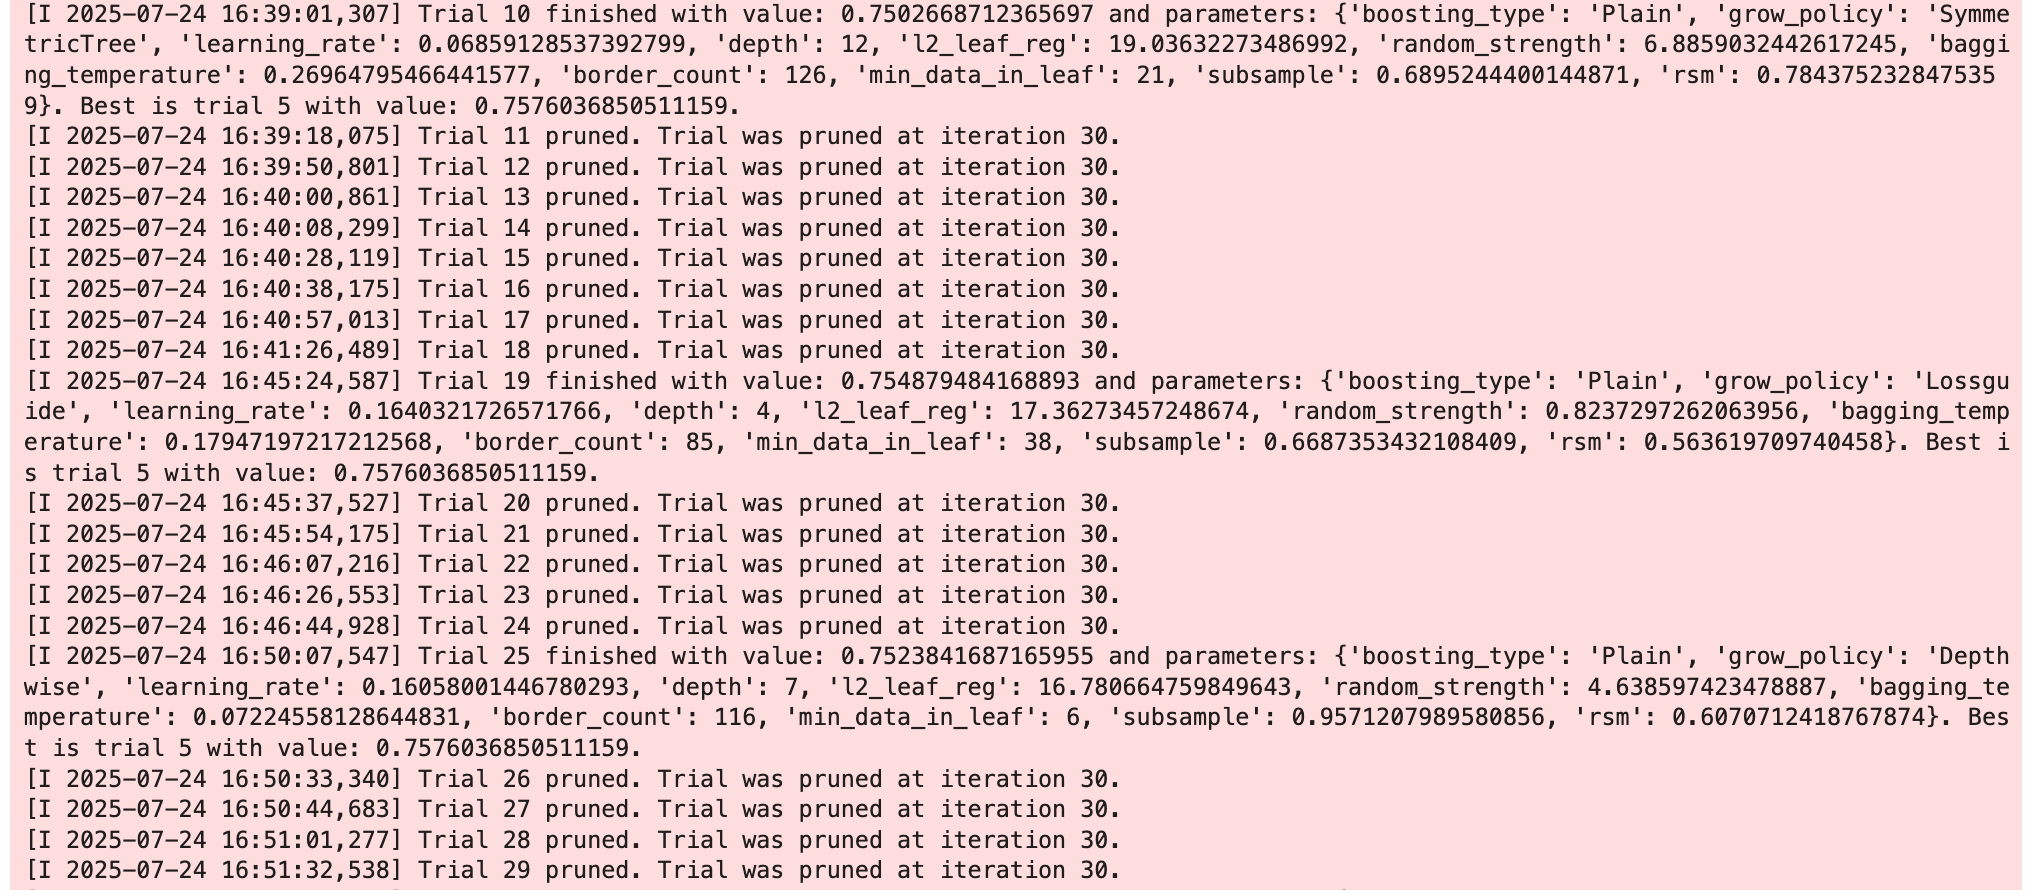
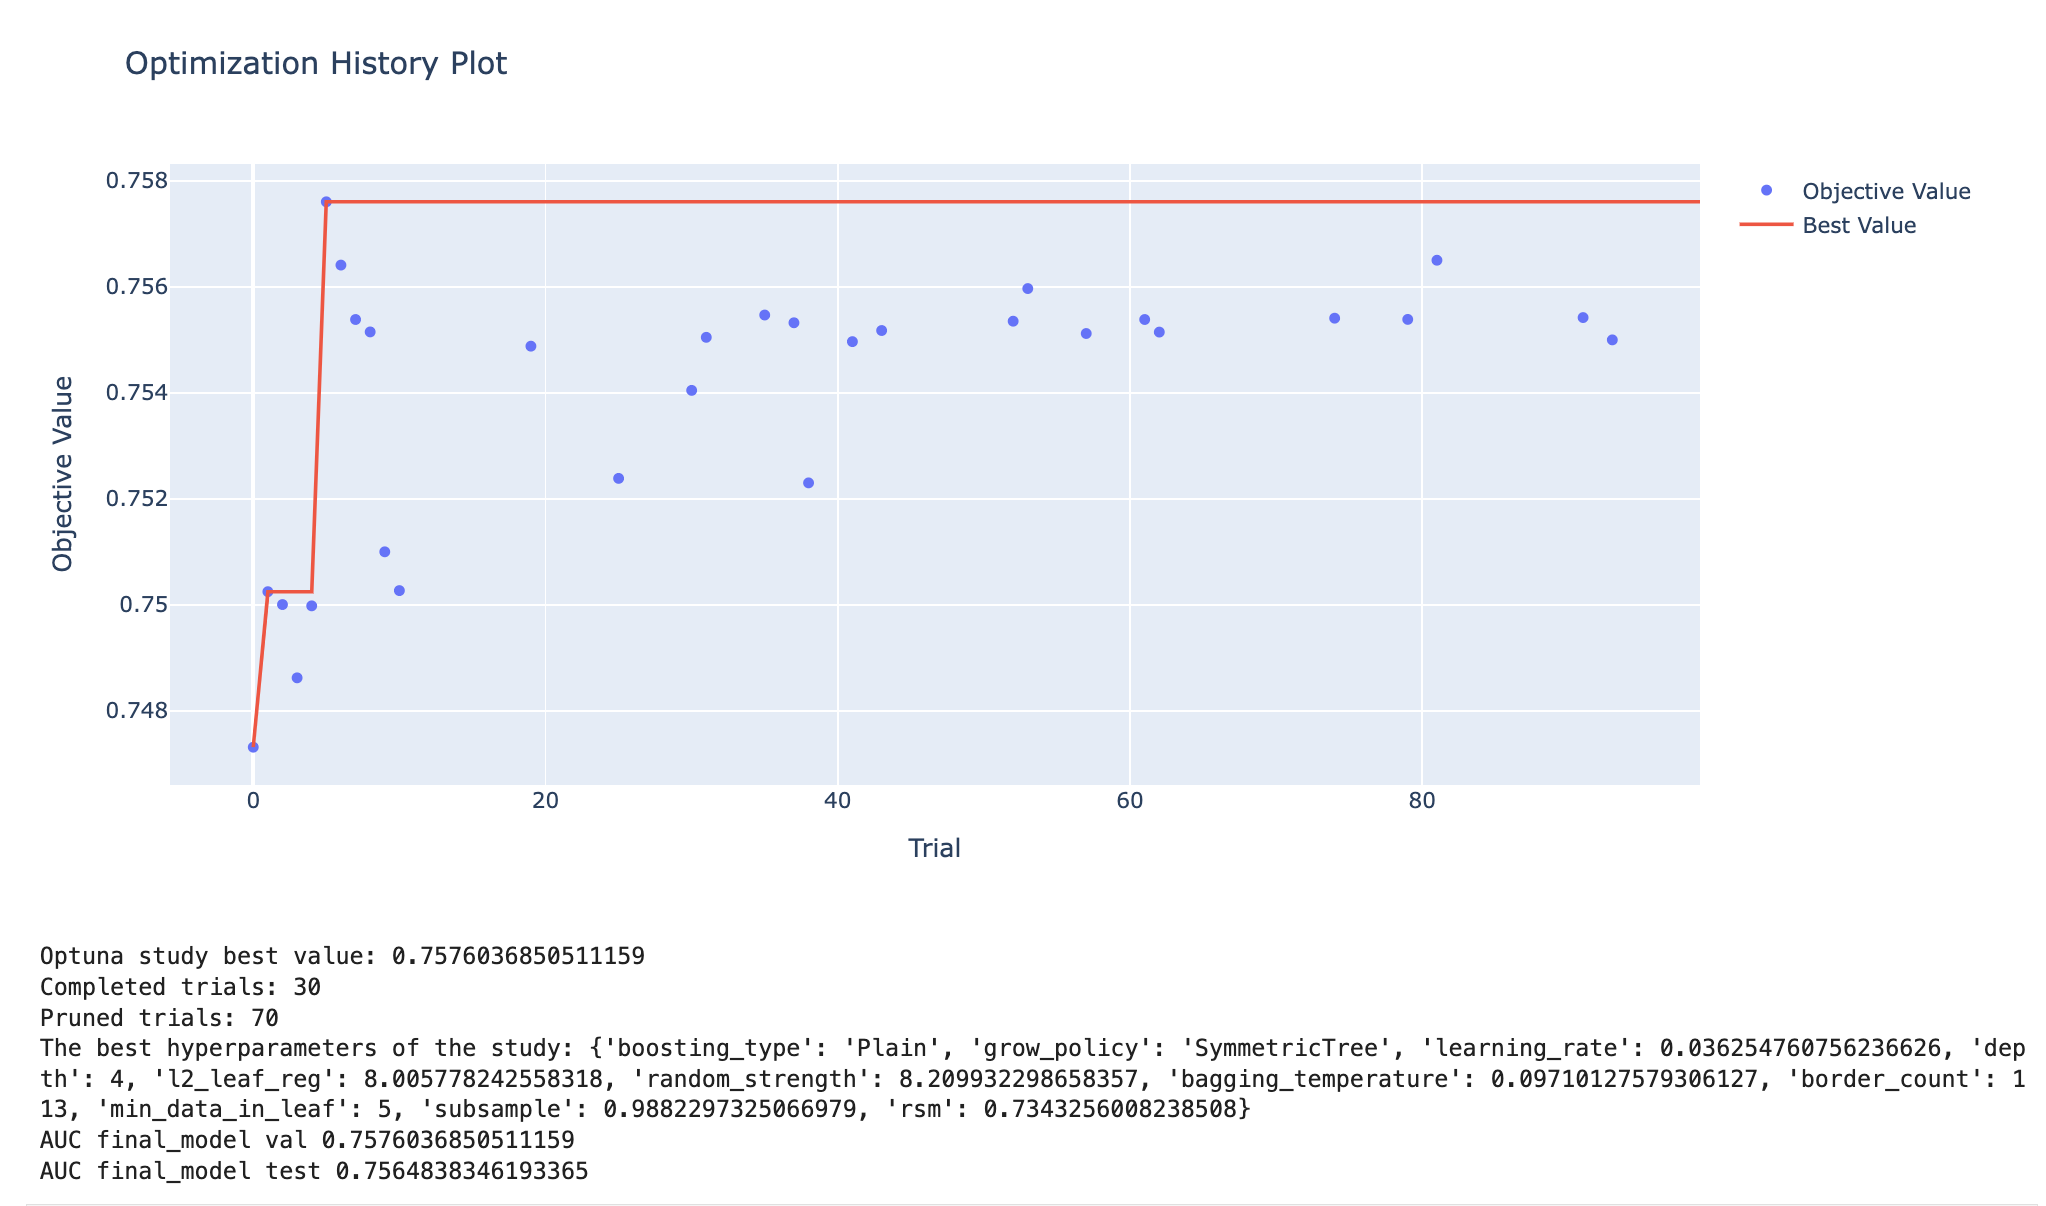

In [28]:
# Сохраненяем модель в файл
model.save_model("../models/fold_0_conservative_model.bin")

In [29]:
# Добавляем метрику в список
val_auc_list.append(val_auc)

In [30]:
"""
Переписываем набор гиперпараметров 
для обучения модели на всех данных и добавляем в словарь количество итераций,
так как обучение будет проходить без валидационной выборки.
"""
best_all_folds_params = model.get_params()
best_all_folds_params["iterations"] = model.get_best_iteration()

print("New best_all_folds_params", best_all_folds_params)

New best_all_folds_params {'iterations': 2996, 'learning_rate': 0.036254760756236626, 'depth': 4, 'l2_leaf_reg': 8.005778242558318, 'rsm': 0.7343256008238508, 'border_count': 113, 'random_seed': 0, 'verbose': False, 'auto_class_weights': 'Balanced', 'random_strength': 8.209932298658357, 'eval_metric': 'AUC', 'bagging_temperature': 0.09710127579306127, 'boosting_type': 'Plain', 'subsample': 0.9882297325066979, 'early_stopping_rounds': 100, 'grow_policy': 'SymmetricTree', 'min_data_in_leaf': 5}


In [31]:
# Сохраняем словарь с лучшими ГП и список метрик в файл
with open("../models/best_conservative_params.pkl", "wb") as f:
    pickle.dump(
        {"best_all_folds_params": best_all_folds_params, "val_auc_list": val_auc_list},
        f,
    )

In [ ]:
# Fold 1
model, val_auc = catboost_optuna_conservative(
    X_train_list[1],
    y_train_list[1],
    X_val_list[1],
    y_val_list[1],
    X_test,
    y_test,
    seed=0,
    iterations=3_000,
    n_trials=100,
    n_startup_trials=10,
    n_warmup_steps=30,
    cat_features=[],
    study_name="fold_1_conservative",
)

In [33]:
# Сохраненяем модель в файл
model.save_model("../models/fold_1_conservative_model.bin")

In [34]:
# Загружаем состояние переменных из файла
with open("../models/best_conservative_params.pkl", "rb") as f:
    state = pickle.load(f)

best_all_folds_params = state["best_all_folds_params"]
val_auc_list = state["val_auc_list"]

In [35]:
"""
Если это лучшая AUC на валидации по фолдам то переписываем набор гиперпараметров 
для обучения модели на всех данных и добавляем в словарь количество итераций,
так как обучение будет проходить без валидационной выборки.
"""
if max(val_auc_list) < val_auc:
    best_all_folds_params = model.get_params()
    best_all_folds_params["iterations"] = model.get_best_iteration()

    print("New best_all_folds_params", best_all_folds_params)
else:
    print("No update. Current best_all_folds_params", best_all_folds_params)

No update. Current best_all_folds_params {'iterations': 2996, 'learning_rate': 0.036254760756236626, 'depth': 4, 'l2_leaf_reg': 8.005778242558318, 'rsm': 0.7343256008238508, 'border_count': 113, 'random_seed': 0, 'verbose': False, 'auto_class_weights': 'Balanced', 'random_strength': 8.209932298658357, 'eval_metric': 'AUC', 'bagging_temperature': 0.09710127579306127, 'boosting_type': 'Plain', 'subsample': 0.9882297325066979, 'early_stopping_rounds': 100, 'grow_policy': 'SymmetricTree', 'min_data_in_leaf': 5}


In [36]:
# Добавляем новую метрику в список
val_auc_list.append(val_auc)

In [37]:
# Сохраняем словарь с лучшими ГП и список метрик в файл
with open("../models/best_conservative_params.pkl", "wb") as f:
    pickle.dump(
        {"best_all_folds_params": best_all_folds_params, "val_auc_list": val_auc_list},
        f,
    )

In [ ]:
# Fold 2
model, val_auc = catboost_optuna_conservative(
    X_train_list[2],
    y_train_list[2],
    X_val_list[2],
    y_val_list[2],
    X_test,
    y_test,
    seed=0,
    iterations=3_000,
    n_trials=100,
    n_startup_trials=10,
    n_warmup_steps=30,
    cat_features=[],
    study_name="fold_2_conservative",
)

In [39]:
# Сохраненяем модель в файл
model.save_model("../models/fold_2_conservative_model.bin")

In [40]:
# Загружаем состояние переменных из файла
with open("../models/best_conservative_params.pkl", "rb") as f:
    state = pickle.load(f)

best_all_folds_params = state["best_all_folds_params"]
val_auc_list = state["val_auc_list"]

In [41]:
"""
Если это лучшая AUC на валидации по фолдам то переписываем набор гиперпараметров 
для обучения модели на всех данных и добавляем в словарь количество итераций,
так как обучение будет проходить без валидационной выборки.
"""
if max(val_auc_list) < val_auc:
    best_all_folds_params = model.get_params()
    best_all_folds_params["iterations"] = model.get_best_iteration()

    print("New best_all_folds_params", best_all_folds_params)
else:
    print("No update. Current best_all_folds_params", best_all_folds_params)

No update. Current best_all_folds_params {'iterations': 2996, 'learning_rate': 0.036254760756236626, 'depth': 4, 'l2_leaf_reg': 8.005778242558318, 'rsm': 0.7343256008238508, 'border_count': 113, 'random_seed': 0, 'verbose': False, 'auto_class_weights': 'Balanced', 'random_strength': 8.209932298658357, 'eval_metric': 'AUC', 'bagging_temperature': 0.09710127579306127, 'boosting_type': 'Plain', 'subsample': 0.9882297325066979, 'early_stopping_rounds': 100, 'grow_policy': 'SymmetricTree', 'min_data_in_leaf': 5}


In [42]:
# Добавляем новую метрику в список
val_auc_list.append(val_auc)

In [43]:
# Сохраняем словарь с лучшими ГП и список метрик в файл
with open("../models/best_conservative_params.pkl", "wb") as f:
    pickle.dump(
        {"best_all_folds_params": best_all_folds_params, "val_auc_list": val_auc_list},
        f,
    )

In [ ]:
# Fold 3
model, val_auc = catboost_optuna_conservative(
    X_train_list[3],
    y_train_list[3],
    X_val_list[3],
    y_val_list[3],
    X_test,
    y_test,
    seed=0,
    iterations=3_000,
    n_trials=100,
    n_startup_trials=10,
    n_warmup_steps=30,
    cat_features=[],
    study_name="fold_3_conservative",
)

In [45]:
# Сохраненяем модель в файл
model.save_model("../models/fold_3_conservative_model.bin")

In [46]:
# Загружаем состояние переменных из файла
with open("../models/best_conservative_params.pkl", "rb") as f:
    state = pickle.load(f)

best_all_folds_params = state["best_all_folds_params"]
val_auc_list = state["val_auc_list"]

In [47]:
"""
Если это лучшая AUC на валидации по фолдам то переписываем набор гиперпараметров 
для обучения модели на всех данных и добавляем в словарь количество итераций,
так как обучение будет проходить без валидационной выборки.
"""
if max(val_auc_list) < val_auc:
    best_all_folds_params = model.get_params()
    best_all_folds_params["iterations"] = model.get_best_iteration()

    print("New best_all_folds_params", best_all_folds_params)
else:
    print("No update. Current best_all_folds_params", best_all_folds_params)

No update. Current best_all_folds_params {'iterations': 2996, 'learning_rate': 0.036254760756236626, 'depth': 4, 'l2_leaf_reg': 8.005778242558318, 'rsm': 0.7343256008238508, 'border_count': 113, 'random_seed': 0, 'verbose': False, 'auto_class_weights': 'Balanced', 'random_strength': 8.209932298658357, 'eval_metric': 'AUC', 'bagging_temperature': 0.09710127579306127, 'boosting_type': 'Plain', 'subsample': 0.9882297325066979, 'early_stopping_rounds': 100, 'grow_policy': 'SymmetricTree', 'min_data_in_leaf': 5}


In [48]:
# Добавляем новую метрику в список
val_auc_list.append(val_auc)

In [49]:
# Сохраняем словарь с лучшими ГП и список метрик в файл
with open("../models/best_conservative_params.pkl", "wb") as f:
    pickle.dump(
        {"best_all_folds_params": best_all_folds_params, "val_auc_list": val_auc_list},
        f,
    )

In [ ]:
# Fold 4
model, val_auc = catboost_optuna_conservative(
    X_train_list[4],
    y_train_list[4],
    X_val_list[4],
    y_val_list[4],
    X_test,
    y_test,
    seed=0,
    iterations=3_000,
    n_trials=100,
    n_startup_trials=10,
    n_warmup_steps=30,
    cat_features=[],
    study_name="fold_4_conservative",
)

In [51]:
# Сохраненяем модель в файл
model.save_model("../models/fold_4_conservative_model.bin")

In [52]:
# Загружаем состояние переменных из файла
with open("../models/best_conservative_params.pkl", "rb") as f:
    state = pickle.load(f)

best_all_folds_params = state["best_all_folds_params"]
val_auc_list = state["val_auc_list"]

In [53]:
"""
Если это лучшая AUC на валидации по фолдам то переписываем набор гиперпараметров 
для обучения модели на всех данных и добавляем в словарь количество итераций,
так как обучение будет проходить без валидационной выборки.
"""
if max(val_auc_list) < val_auc:
    best_all_folds_params = model.get_params()
    best_all_folds_params["iterations"] = model.get_best_iteration()

    print("New best_all_folds_params", best_all_folds_params)
else:
    print("No update. Current best_all_folds_params", best_all_folds_params)

No update. Current best_all_folds_params {'iterations': 2996, 'learning_rate': 0.036254760756236626, 'depth': 4, 'l2_leaf_reg': 8.005778242558318, 'rsm': 0.7343256008238508, 'border_count': 113, 'random_seed': 0, 'verbose': False, 'auto_class_weights': 'Balanced', 'random_strength': 8.209932298658357, 'eval_metric': 'AUC', 'bagging_temperature': 0.09710127579306127, 'boosting_type': 'Plain', 'subsample': 0.9882297325066979, 'early_stopping_rounds': 100, 'grow_policy': 'SymmetricTree', 'min_data_in_leaf': 5}


In [54]:
# Добавляем новую метрику в список
val_auc_list.append(val_auc)

In [55]:
val_auc_list

[0.7576036850511159,
 0.7554545982995526,
 0.7532810994057619,
 0.7546988571803108,
 0.7524269260453276]

In [56]:
# Обучаем модель на всех тренировочных данных
train_pool = Pool(data=X, label=y, cat_features=[])

model = CatBoostClassifier(**best_all_folds_params)
model.fit(train_pool)

# Выводим  AUC на всех данных
proba = model.predict_proba(X)[:, 1]
auc = roc_auc_score(y, proba)
print("AUC full_data_model train ", auc)

# Выводим  AUC на тесте
proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)
print("AUC full_data_model test ", auc)

AUC full_data_model train  0.7666397313737999
AUC full_data_model test  0.7568409251889248


In [57]:
# Сохраненяем модель в файл
model.save_model("../models/full_data_conservative_model.bin")

In [58]:
"""
В список метрик добавим среднее AUC по моделям фолдов
как вес для модели обученной на всех данных.
"""
val_auc_list.append(np.mean(val_auc_list))

# Сохраняем список  в файл
with open("../models/conservative_models_weights.pkl", "wb") as f:
    pickle.dump({"val_auc_list": val_auc_list}, f)

In [59]:
# Соберём словарь с моделями и их метриками
models_dict = {}
for i in range(5):
    model = CatBoostClassifier()
    model.load_model(f"../models/fold_{i}_conservative_model.bin")
    models_dict[f"fold_{i}_model"] = (model, val_auc_list[i])

model = CatBoostClassifier()
model.load_model("../models/full_data_conservative_model.bin")
models_dict["full_data_model"] = (model, val_auc_list[5])
models_dict

{'fold_0_model': (<catboost.core.CatBoostClassifier at 0x14c904c80>,
  0.7576036850511159),
 'fold_1_model': (<catboost.core.CatBoostClassifier at 0x14d309af0>,
  0.7554545982995526),
 'fold_2_model': (<catboost.core.CatBoostClassifier at 0x14d6dc0e0>,
  0.7532810994057619),
 'fold_3_model': (<catboost.core.CatBoostClassifier at 0x14c6b3bf0>,
  0.7546988571803108),
 'fold_4_model': (<catboost.core.CatBoostClassifier at 0x14c904680>,
  0.7524269260453276),
 'full_data_model': (<catboost.core.CatBoostClassifier at 0x14d7391f0>,
  0.7546930331964138)}

In [60]:
"""
Собираем средневзвешенный по AUC предикт вероятностей классов 
на всех моделях фолдов и финальной моделе.
"""

df_pred = pd.DataFrame()

# Для каждой модели из словаря models_dict
for model_name, value in models_dict.items():
    # Получаем вероятности положительного класса на тестовой выборке
    pred = value[0].predict_proba(X_test)[:, 1]
    # Умножаем предсказания на вес модели (AUC на валидации или средний AUC)
    pred_coef = pred * value[1]
    # Сохраняем взвешенные предсказания в DataFrame
    df_pred[model_name] = pred_coef

# Суммируем веса всех моделей
weights_sum = sum(val[1] for val in models_dict.values())
# Формируем итоговое взвешенное среднее предсказание ансамбля
df_pred["ensemble_weighted_pred"] = df_pred.sum(axis=1) / weights_sum
# Получаем AUC ансамбля на тесте
auc = roc_auc_score(y_test, df_pred["ensemble_weighted_pred"])
print("AUC ensemble weighted test", auc)

AUC ensemble weighted test 0.7572337893426191


In [61]:
df_pred

,fold_0_model,fold_1_model,fold_2_model,fold_3_model,fold_4_model,full_data_model,ensemble_weighted_pred
0,0.311332,0.281306,0.310687,0.301043,0.305799,0.303800,0.400597
1,0.458813,0.443951,0.440193,0.428172,0.433123,0.412836,0.577959
2,0.371575,0.391391,0.378054,0.363470,0.374276,0.366214,0.495782
3,0.247007,0.236710,0.237670,0.256054,0.209763,0.196154,0.305501
4,0.386261,0.399735,0.365984,0.399634,0.373339,0.402774,0.514056
...,...,...,...,...,...,...,...
599995,0.356894,0.385319,0.378197,0.378471,0.371458,0.388989,0.498951
599996,0.218918,0.196052,0.229173,0.215380,0.231841,0.214060,0.288290
599997,0.075869,0.084478,0.072349,0.063650,0.079298,0.080528,0.100741
599998,0.436347,0.415625,0.415014,0.430303,0.445256,0.422070,0.566371


Итоговые предсказанные вероятности не выглядят как простое среднее по предсказаниям моделей, потому что предсказания умножаются на веса моделей (примерно 0.75), что уменьшает их значения. Однако деление суммы взвешенных предсказаний на сумму весов восстанавливает правильный масштаб  итоговых вероятностей.  
Классическая и агрессивная схема показали почти одинаковые результаты на тестовой выборке (0.7572, 0.756) 
поэтому особой разницы какую из них использовать в пайплайне и для построения ROC кривой нет.     
Сделаем выбор в пользу классической схемы как более надёжной.